# 🔍 VeriLex.ai — Font Inconsistency Detection CNN

---

## 📋 What this notebook does:
| Step | Description |
|------|-------------|
| 1 | Enable GPU & install libraries |
| 2 | Generate synthetic labelled dataset (GENUINE vs FRAUD) |
| 3 | Build CNN model (EfficientNet-B0) |
| 4 | Train the model |
| 5 | Evaluate accuracy & view results |
| 6 | Run inference on your own document image |
| 7 | Download the trained model |

---
> ⚠️ **Before running:** Go to `Runtime → Change Runtime Type → T4 GPU` → Save

## ✅ STEP 1 — Check GPU & Install Libraries

In [2]:
# Check if GPU is available
import torch
print('PyTorch version :', torch.__version__)
print('GPU available   :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name        :', torch.cuda.get_device_name(0))
else:
    print('⚠️  No GPU detected. Go to Runtime → Change Runtime Type → T4 GPU')

ModuleNotFoundError: No module named 'torch'

In [ ]:
# Install required libraries (torch & torchvision already in Colab)
!pip install -q scikit-learn matplotlib tqdm Pillow
print('✅ All libraries ready!')

✅ All libraries ready!


## ✅ STEP 2 — Imports & Configuration

In [13]:
import os, random, numpy as np
from pathlib import Path
from typing import Tuple, List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

# ── Reproducibility ──────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('✅ Imports done')

✅ Imports done


In [21]:
# ── CONFIG — change these values to experiment ────────
class Config:
    DATA_DIR         = Path('/content/data/font_dataset')
    MODEL_DIR        = Path('/content/models')
    RESULTS_DIR      = Path('/content/results')

    IMG_SIZE         = 224          # EfficientNet expects 224x224
    NUM_GENUINE      = 1500         # Genuine samples to generate
    NUM_FRAUD        = 1500         # Fraud samples to generate
    VAL_SPLIT        = 0.15
    TEST_SPLIT       = 0.10

    BATCH_SIZE       = 32
    EPOCHS           = 20           # Increase for better accuracy
    LR               = 1e-4
    WEIGHT_DECAY     = 1e-4
    DROPOUT          = 0.5
    DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'

    CLASSES          = ['GENUINE', 'FRAUD']   # 0 = genuine, 1 = fraud

    # Font sizes used in synthesis
    FONT_SIZES_GENUINE = [14, 16]              # Consistent (genuine)
    FONT_SIZES_FRAUD   = [10, 14, 18, 22]      # Inconsistent (fraud)

cfg = Config()

for d in [cfg.DATA_DIR, cfg.MODEL_DIR, cfg.RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'✅ Config ready | Device: {cfg.DEVICE.upper()}')

✅ Config ready | Device: CUDA


## ✅ STEP 3 — Generate Synthetic Dataset

Since we don't have a real dataset, we **simulate** legal document text patches:
- **GENUINE** → All lines use the same font size (consistent document)
- **FRAUD** → Each line has a random different font size (copy-paste forgery)

> 💡 After you collect real data, replace this with your actual images!

In [15]:
# Sample legal document lines for synthesis
LEGAL_LINES = [
    'This agreement is entered into on the date mentioned herein.',
    'The party of the first part hereinafter referred to as Plaintiff.',
    'Whereas the court has examined all documents submitted.',
    'Pursuant to Section 144 of the Civil Procedure Code.',
    'The undersigned hereby certifies the authenticity of records.',
    'Order issued by the Hon\'ble District Court, Bilaspur.',
    'All parties are required to appear on the scheduled date.',
    'Failure to comply shall result in contempt proceedings.',
    'Signed and sealed in the presence of the witnesses below.',
    'The document bears the official stamp of the issuing authority.',
    'Reference: Case No. 2024/CIV/00842, District Court.',
    'Government of India, Ministry of Law and Justice notification.',
    'This order shall take effect from the date of issuance.',
]


def get_font(size=14):
    """Load a font; falls back to PIL default if no TTF found."""
    font_paths = [
        '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',         # Linux (Colab)
        '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
        '/usr/share/fonts/truetype/freefont/FreeSans.ttf',
    ]
    for p in font_paths:
        if os.path.exists(p):
            try:
                return ImageFont.truetype(p, size)
            except Exception:
                pass
    return ImageFont.load_default()


def create_genuine_patch():
    """All text lines use the SAME font size → GENUINE (label=0)"""
    img  = Image.new('RGB', (224, 224), color=(255, 255, 255))
    draw = ImageDraw.Draw(img)
    size = random.choice(cfg.FONT_SIZES_GENUINE)
    font = get_font(size)
    y = 10
    for line in random.sample(LEGAL_LINES, k=8):
        draw.text((10, y), line, fill=(20, 20, 20), font=font)
        y += size + 8
        if y > 200: break
    # Subtle uniform noise
    arr = np.array(img, dtype=np.float32)
    arr += np.random.normal(0, 2, arr.shape)
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


def create_fraud_patch():
    """Each line uses a DIFFERENT random font size → FRAUD (label=1)"""
    img  = Image.new('RGB', (224, 224), color=(255, 255, 255))
    draw = ImageDraw.Draw(img)
    y = 10
    for line in random.sample(LEGAL_LINES, k=8):
        size  = random.choice(cfg.FONT_SIZES_FRAUD)   # Random each line!
        font  = get_font(size)
        shade = random.randint(0, 40)                 # Slight color variation
        draw.text((random.randint(5, 20), y), line,
                  fill=(shade, shade, shade), font=font)
        y += size + random.randint(4, 14)
        if y > 200: break
    arr = np.array(img, dtype=np.float32)
    arr += np.random.normal(0, 4, arr.shape)
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


def generate_dataset():
    print('📄 Generating synthetic dataset...')
    for split in ['train', 'val', 'test']:
        for cls in cfg.CLASSES:
            (cfg.DATA_DIR / split / cls).mkdir(parents=True, exist_ok=True)

    def save_split(fn, label, total):
        n_test  = int(total * cfg.TEST_SPLIT)
        n_val   = int(total * cfg.VAL_SPLIT)
        n_train = total - n_test - n_val
        idx = 0
        for split, count in [('train', n_train), ('val', n_val), ('test', n_test)]:
            for _ in range(count):
                fn().save(cfg.DATA_DIR / split / label / f'{label}_{idx:05d}.png')
                idx += 1

    save_split(create_genuine_patch, 'GENUINE', cfg.NUM_GENUINE)
    save_split(create_fraud_patch,   'FRAUD',   cfg.NUM_FRAUD)

    # Count files
    for split in ['train', 'val', 'test']:
        g = len(list((cfg.DATA_DIR/split/'GENUINE').glob('*.png')))
        f = len(list((cfg.DATA_DIR/split/'FRAUD').glob('*.png')))
        print(f'  {split:5s} → GENUINE: {g} | FRAUD: {f}')
    print('✅ Dataset ready!')


generate_dataset()

📄 Generating synthetic dataset...


KeyboardInterrupt: 

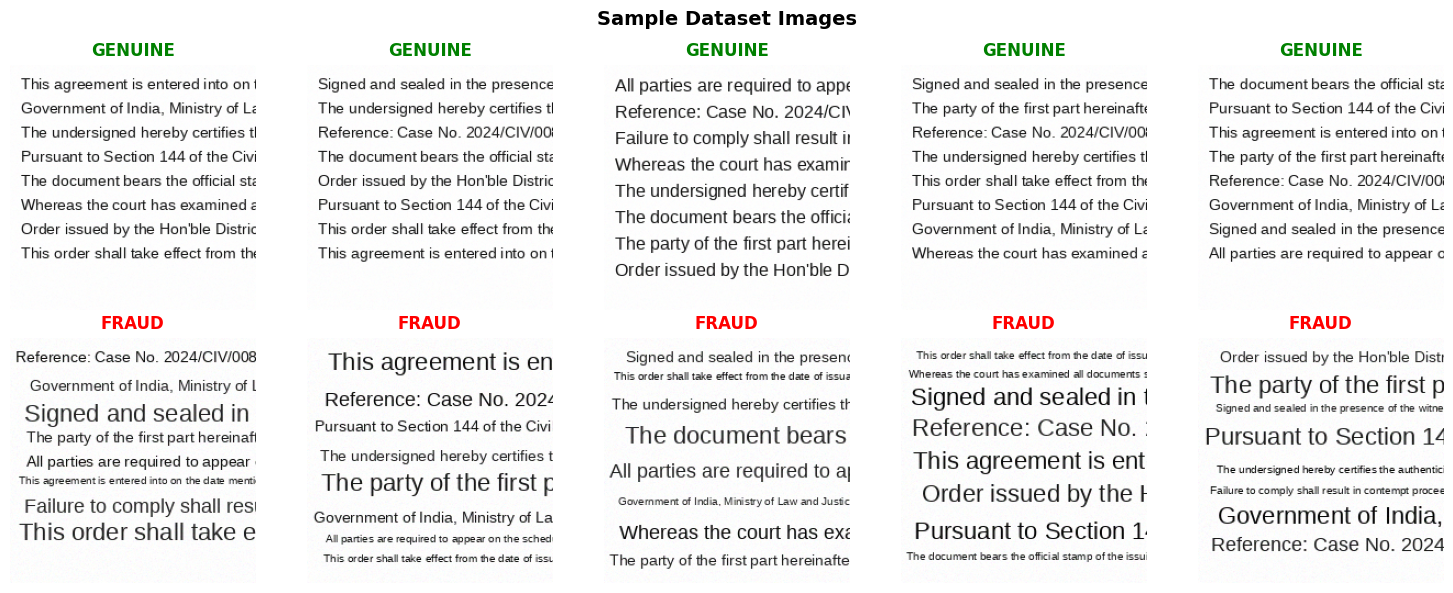

✅ Sample images shown above


In [14]:
# 👀 Visualise sample images from dataset
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Dataset Images', fontsize=14, fontweight='bold')

for col in range(5):
    axes[0][col].imshow(create_genuine_patch())
    axes[0][col].set_title('GENUINE', color='green', fontweight='bold')
    axes[0][col].axis('off')

    axes[1][col].imshow(create_fraud_patch())
    axes[1][col].set_title('FRAUD', color='red', fontweight='bold')
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig(cfg.RESULTS_DIR / 'sample_images.png', dpi=120)
plt.show()
print('✅ Sample images shown above')

## ✅ STEP 4 — Dataset Class & Data Loaders

In [7]:
class FontDataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.transform = transform
        self.samples   = []
        for label_idx, cls in enumerate(cfg.CLASSES):
            cls_dir = root / split / cls
            for img_path in sorted(cls_dir.glob('*.png')):
                self.samples.append((img_path, label_idx))
        random.shuffle(self.samples)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label


def get_transforms(split):
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(3),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])


loaders = {}
for split in ['train', 'val', 'test']:
    ds = FontDataset(cfg.DATA_DIR, split, transform=get_transforms(split))
    loaders[split] = DataLoader(ds, batch_size=cfg.BATCH_SIZE,
                                 shuffle=(split=='train'),
                                 num_workers=2, pin_memory=True)
    print(f'  {split:5s}: {len(ds)} samples')

print('\n✅ DataLoaders ready!')

  train: 2250 samples
  val  : 450 samples
  test : 300 samples

✅ DataLoaders ready!


## ✅ STEP 5 — Build the CNN Model

We use **EfficientNet-B0** pre-trained on ImageNet as the backbone.
The custom head learns to detect font fraud signals.

```
EfficientNet-B0 (ImageNet backbone)
    └── Dropout(0.5)
    └── Linear(1280 → 512) + ReLU + BatchNorm
    └── Dropout(0.3)
    └── Linear(512 → 2)  ← GENUINE / FRAUD
```

In [8]:
class FontFraudCNN(nn.Module):
    def __init__(self, num_classes=2, freeze_backbone=True):
        super().__init__()
        # Load pretrained EfficientNet-B0
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # Replace the final classifier head
        in_features = self.backbone.classifier[1].in_features  # 1280
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=cfg.DROPOUT),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes),
        )

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def forward(self, x):
        return self.backbone(x)


model = FontFraudCNN(num_classes=2, freeze_backbone=True).to(cfg.DEVICE)

total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model ready on {cfg.DEVICE.upper()}')
print(f'   Total params     : {total:,}')
print(f'   Trainable params : {trainable:,}  (backbone frozen for first 5 epochs)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 162MB/s]


✅ Model ready on CUDA
   Total params     : 4,665,470
   Trainable params : 657,922  (backbone frozen for first 5 epochs)


## ✅ STEP 6 — Train the Model

**Training strategy:**
- Epochs 1–5 → Only train the custom head (backbone frozen) — fast warm-up
- Epoch 6+ → Unfreeze full network and fine-tune everything at a lower LR

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0


def run_epoch(split):
    training = (split == 'train')
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loaders[split]:
            imgs, labels = imgs.to(cfg.DEVICE), labels.to(cfg.DEVICE)
            if training: optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


print(f'🚀 Training on {cfg.DEVICE.upper()} for {cfg.EPOCHS} epochs\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | Note')
print('-' * 72)

for epoch in range(1, cfg.EPOCHS + 1):

    # Unfreeze backbone after warm-up
    if epoch == 6:
        model.unfreeze_backbone()
        optimizer = optim.AdamW(model.parameters(),
                                lr=cfg.LR * 0.1, weight_decay=cfg.WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=cfg.EPOCHS - 5)

    tr_loss, tr_acc = run_epoch('train')
    vl_loss, vl_acc = run_epoch('val')
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    note = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), cfg.MODEL_DIR / 'best_font_fraud_cnn.pt')
        note = '✅ saved'
    if epoch == 6:
        note += ' 🔓 backbone unfrozen'

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | '
          f'{vl_loss:>8.4f} | {vl_acc:>7.4f} | {note}')

print(f'\n🏆 Best Validation Accuracy: {best_val_acc:.4f}')

🚀 Training on CUDA for 20 epochs

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Note
------------------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
# 📊 Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VeriLex.ai — Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(history['val_loss'],   'r-o', label='Val',   markersize=4)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['train_acc'], 'b-o', label='Train', markersize=4)
axes[1].plot(history['val_acc'],   'r-o', label='Val',   markersize=4)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(cfg.RESULTS_DIR / 'training_curves.png', dpi=150)
plt.show()

## ✅ STEP 7 — Evaluate on Test Set

In [ ]:
# Load best saved model
model.load_state_dict(
    torch.load(cfg.MODEL_DIR / 'best_font_fraud_cnn.pt', map_location=cfg.DEVICE)
)
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in loaders['test']:
        imgs   = imgs.to(cfg.DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

print('📋 Classification Report')
print('=' * 50)
print(classification_report(all_labels, all_preds, target_names=cfg.CLASSES))

In [ ]:
# Confusion Matrix
cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cfg.CLASSES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig(cfg.RESULTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# Summary
tn, fp, fn, tp = cm.ravel()
precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
recall     = tp / (tp + fn) if (tp + fn) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
print(f'\n📊 Fraud Detection Metrics')
print(f'   Precision  : {precision:.4f}  (of docs flagged as FRAUD, how many are actually FRAUD)')
print(f'   Recall     : {recall:.4f}  (of actual FRAUD docs, how many were caught)')
print(f'   F1 Score   : {f1:.4f}')
print(f'   False Positives (genuine flagged as fraud) : {fp}')
print(f'   False Negatives (fraud missed)             : {fn}')

## ✅ STEP 8 — Run Inference on Your Own Document

Upload any document image and test it!

In [ ]:
# ── Inference Engine ──────────────────────────────────────────────────────
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def predict(img_input):
    """
    Predict GENUINE or FRAUD for a document image.
    img_input: file path (str) OR PIL.Image object
    """
    if isinstance(img_input, (str, Path)):
        img = Image.open(img_input).convert('RGB')
    else:
        img = img_input.convert('RGB')

    tensor = infer_transform(img).unsqueeze(0).to(cfg.DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]

    genuine_score = probs[0].item()
    fraud_score   = probs[1].item()
    label         = cfg.CLASSES[probs.argmax().item()]

    if fraud_score < 0.35:
        risk, reason = 'LOW',    'Fonts appear consistent. No anomalies detected.'
    elif fraud_score < 0.65:
        risk, reason = 'MEDIUM', 'Moderate inconsistencies. Manual review recommended.'
    else:
        risk, reason = 'HIGH',   'High font inconsistency — likely copy-paste forgery!'

    return {
        'label':         label,
        'fraud_score':   round(fraud_score, 4),
        'genuine_score': round(genuine_score, 4),
        'risk_level':    risk,
        'explanation':   reason,
    }


def show_prediction(img, title=''):
    result = predict(img)
    color  = 'red' if result['label'] == 'FRAUD' else 'green'

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img if isinstance(img, Image.Image) else Image.open(img))
    axes[0].set_title(f'{title}', fontsize=11)
    axes[0].axis('off')

    # Result panel
    axes[1].axis('off')
    result_text = (
        f"VERDICT: {result['label']}\n\n"
        f"Fraud Score  : {result['fraud_score']:.4f}\n"
        f"Genuine Score: {result['genuine_score']:.4f}\n"
        f"Risk Level   : {result['risk_level']}\n\n"
        f"{result['explanation']}"
    )
    axes[1].text(0.1, 0.5, result_text, transform=axes[1].transAxes,
                 fontsize=12, verticalalignment='center',
                 bbox=dict(boxstyle='round', facecolor=color, alpha=0.2),
                 fontfamily='monospace')
    plt.tight_layout()
    plt.show()
    return result

print('✅ Inference engine ready!')

In [ ]:
# 🧪 Test with synthetic FRAUD document
fraud_img   = create_fraud_patch()
genuine_img = create_genuine_patch()

print('Testing on FRAUD document:')
r1 = show_prediction(fraud_img, 'Synthetic FRAUD Document')

print('Testing on GENUINE document:')
r2 = show_prediction(genuine_img, 'Synthetic GENUINE Document')

In [ ]:
# 📁 Upload YOUR OWN document image and test it
# Run this cell, click 'Choose Files', upload any document scan/screenshot
from google.colab import files

print('📤 Upload a document image (PNG or JPG)...')
uploaded = files.upload()

for filename, data in uploaded.items():
    img = Image.open(__import__('io').BytesIO(data)).convert('RGB')
    print(f'\n🔍 Analysing: {filename}')
    result = show_prediction(img, filename)
    print(f'\nFinal Result: {result}')

## ✅ STEP 9 — Download the Trained Model

Download your trained model to use in the FastAPI backend.

In [ ]:
from google.colab import files

# Download the best model checkpoint
model_path = str(cfg.MODEL_DIR / 'best_font_fraud_cnn.pt')
print(f'📦 Model size: {os.path.getsize(model_path) / 1e6:.1f} MB')
files.download(model_path)

# Also download the training curves and confusion matrix
files.download(str(cfg.RESULTS_DIR / 'training_curves.png'))
files.download(str(cfg.RESULTS_DIR / 'confusion_matrix.png'))

print('✅ Downloaded: model + result plots')
print('\n📌 To use this model in FastAPI:')
print('   1. Place best_font_fraud_cnn.pt in your backend/models/ folder')
print('   2. Use the VeriLexInference class from verilex_font_cnn.py')
print('   3. POST a document image to /verify/font')

In [ ]:
# STEP 1 — Install the datasets library
!pip install -q datasets
print("✅ Library installed")

In [ ]:
# STEP 2 — Download 500 real scanned documents
from datasets import load_dataset
import os

print("⏳ Downloading real documents... (takes ~2 mins)")
dataset = load_dataset("rvl_cdip", split="train[:500]", trust_remote_code=True)
print(f"✅ Loaded {len(dataset)} real document images")

# Save them to disk
os.makedirs("/content/real_docs", exist_ok=True)
for i, sample in enumerate(dataset):
    sample['image'].save(f"/content/real_docs/doc_{i:04d}.png")
    if i % 100 == 0:
        print(f"  Saved {i}/500...")

print("✅ All saved to /content/real_docs/")

In [ ]:
# STEP 3 — Preview what the real documents look like
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Real Scanned Documents from RVL-CDIP", fontsize=13, fontweight='bold')

files = sorted(os.listdir("/content/real_docs"))[:10]
for i, ax in enumerate(axes.flatten()):
    img = Image.open(f"/content/real_docs/{files[i]}").convert("RGB")
    ax.imshow(img, cmap='gray')
    ax.set_title(f"doc_{i}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# STEP 4 — Run your trained model on all 500 real docs
from PIL import Image
import os

doc_files = sorted([f for f in os.listdir("/content/real_docs")
                    if f.endswith('.png')])

print(f"🔍 Testing model on {len(doc_files)} real documents...\n")
print(f"{'File':30s} | {'Label':7s} | {'Fraud Score':11s} | {'Risk':6s}")
print("-" * 65)

fraud_count   = 0
genuine_count = 0
results_all   = []

for filename in doc_files:
    path   = os.path.join("/content/real_docs", filename)
    img    = Image.open(path).convert("RGB")
    result = predict(img)
    results_all.append((filename, result))

    icon = "🔴" if result['label'] == 'FRAUD' else "🟢"
    print(f"{icon} {filename:28s} | {result['label']:7s} | "
          f"{result['fraud_score']:.4f}      | {result['risk_level']}")

    if result['label'] == 'FRAUD':
        fraud_count += 1
    else:
        genuine_count += 1

print("\n" + "=" * 65)
print(f"📊 SUMMARY")
print(f"   Total documents : {len(doc_files)}")
print(f"   🟢 GENUINE       : {genuine_count} ({genuine_count/len(doc_files)*100:.1f}%)")
print(f"   🔴 FRAUD         : {fraud_count} ({fraud_count/len(doc_files)*100:.1f}%)")

In [ ]:
# STEP 5 — Visualise top 5 highest fraud-score documents
results_sorted = sorted(results_all, key=lambda x: x[1]['fraud_score'], reverse=True)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Top 5 Most Suspicious Documents", fontsize=13, fontweight='bold', color='red')

for i, (filename, result) in enumerate(results_sorted[:5]):
    img = Image.open(f"/content/real_docs/{filename}").convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(
        f"Score: {result['fraud_score']:.3f}\nRisk: {result['risk_level']}",
        fontsize=9, color='red', fontweight='bold'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 🔍 VeriLex.ai — Real Document Testing
### ADD THESE CELLS AFTER CELL 15 IN YOUR EXISTING NOTEBOOK

---

## 📋 What this does:
| Step | Description |
|------|-------------|
| 16 | Install real dataset library |
| 17 | Download 500 real scanned docs (Option A - RVL-CDIP) |
| 18 | Upload YOUR OWN documents (Option B) |
| 19 | Combine both sources into one folder |
| 20 | Preview all documents |
| 21 | Run model on ALL documents |
| 22 | Show top suspicious documents |
| 23 | Full fraud report + download results |

> ⚠️ **Run Cell 12 (predict function) from your original notebook first before starting here!**

## ✅ CELL 16 — Install Library

In [ ]:
# Install required library for Option A
!pip install -q datasets
import os
from PIL import Image
import io

# Create all folders
os.makedirs('/content/real_docs/rvl_cdip',   exist_ok=True)  # Option A
os.makedirs('/content/real_docs/my_uploads', exist_ok=True)  # Option B
os.makedirs('/content/real_docs/combined',   exist_ok=True)  # Both merged
os.makedirs('/content/results',              exist_ok=True)

print('✅ Library installed!')
print('📁 Folders created:')
print('   /content/real_docs/rvl_cdip   ← Option A (RVL-CDIP dataset)')
print('   /content/real_docs/my_uploads ← Option B (your own files)')
print('   /content/real_docs/combined   ← All merged together')

## ✅ CELL 17 — Option A: Download RVL-CDIP Real Documents

In [ ]:
from datasets import load_dataset
import shutil

print('⏳ Downloading 500 real scanned documents from RVL-CDIP...')
print('   (This takes about 2-3 minutes, please wait)\n')

try:
    dataset = load_dataset('rvl_cdip', split='train[:500]', trust_remote_code=True)
    print(f'✅ Downloaded {len(dataset)} real document images')

    print('💾 Saving to disk...')
    for i, sample in enumerate(dataset):
        # Save to rvl_cdip folder
        save_path = f'/content/real_docs/rvl_cdip/rvl_{i:04d}.png'
        sample['image'].convert('RGB').save(save_path)

        # Also copy to combined folder
        shutil.copy(save_path, f'/content/real_docs/combined/rvl_{i:04d}.png')

        if i % 100 == 0:
            print(f'   Saved {i}/500...')

    count = len(os.listdir('/content/real_docs/rvl_cdip'))
    print(f'\n✅ Option A complete! {count} documents saved.')

except Exception as e:
    print(f'❌ Error: {e}')
    print('\n💡 Try running this cell again — sometimes download times out.')

## ✅ CELL 18 — Option B: Upload YOUR OWN Documents

> 📸 Upload photos of real legal documents from your phone or computer
> (court orders, certificates, government letters, ID cards, etc.)

In [ ]:
from google.colab import files
import shutil

print('📤 Upload your own document images (PNG or JPG)...')
print('   Click Choose Files below and select multiple files at once')
print('   (Skip this cell if you only want to use Option A)\n')

try:
    uploaded = files.upload()

    if len(uploaded) == 0:
        print('⚠️  No files uploaded. Continuing with Option A only.')
    else:
        print(f'\n✅ {len(uploaded)} file(s) uploaded!')
        for filename, data in uploaded.items():
            try:
                img = Image.open(io.BytesIO(data)).convert('RGB')

                # Save to my_uploads folder
                clean_name = filename.replace(' ', '_')
                save_path  = f'/content/real_docs/my_uploads/{clean_name}'
                img.save(save_path)

                # Also copy to combined folder
                shutil.copy(save_path, f'/content/real_docs/combined/upload_{clean_name}')
                print(f'   ✅ Saved: {filename}')
            except Exception as e:
                print(f'   ❌ Failed: {filename} — {e}')

        count = len(os.listdir('/content/real_docs/my_uploads'))
        print(f'\n✅ Option B complete! {count} personal documents saved.')

except Exception as e:
    print(f'Upload cancelled or failed: {e}')
    print('Continuing with Option A documents only.')

## ✅ CELL 19 — Combined Summary

In [ ]:
# Count all documents across all sources
rvl_files      = [f for f in os.listdir('/content/real_docs/rvl_cdip')   if f.endswith(('.png','.jpg','.jpeg'))]
upload_files   = [f for f in os.listdir('/content/real_docs/my_uploads') if f.endswith(('.png','.jpg','.jpeg'))]
combined_files = [f for f in os.listdir('/content/real_docs/combined')   if f.endswith(('.png','.jpg','.jpeg'))]

print('📊 Document Summary')
print('=' * 40)
print(f'   Option A (RVL-CDIP)   : {len(rvl_files):4d} documents')
print(f'   Option B (My Uploads) : {len(upload_files):4d} documents')
print(f'   ─────────────────────────────')
print(f'   TOTAL COMBINED        : {len(combined_files):4d} documents')
print('=' * 40)
print(f'\n✅ Ready to test all {len(combined_files)} documents!')

## ✅ CELL 20 — Preview All Documents

In [ ]:
import matplotlib.pyplot as plt
import random

combined_files = sorted([f for f in os.listdir('/content/real_docs/combined')
                          if f.endswith(('.png','.jpg','.jpeg'))])

# Show 10 random samples
sample_files = random.sample(combined_files, min(10, len(combined_files)))

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(f'Sample from Combined Dataset ({len(combined_files)} total docs)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i < len(sample_files):
        img = Image.open(f'/content/real_docs/combined/{sample_files[i]}').convert('RGB')
        ax.imshow(img)
        # Label source
        src   = 'RVL-CDIP' if sample_files[i].startswith('rvl_') else 'MY DOC'
        color = 'blue'     if src == 'RVL-CDIP' else 'purple'
        ax.set_title(f'{src}\n{sample_files[i][:15]}', fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/results/combined_samples.png', dpi=120)
plt.show()
print('✅ Preview complete!')

## ✅ CELL 21 — Run VeriLex Model on ALL Documents

In [ ]:
combined_files = sorted([f for f in os.listdir('/content/real_docs/combined')
                          if f.endswith(('.png','.jpg','.jpeg'))])

print(f'🔍 Running VeriLex.ai on {len(combined_files)} documents...\n')
print(f'{"#":>4} {"File":32s} {"Source":8s} {"Verdict":7s} {"Fraud":6s} {"Risk":6s}')
print('─' * 75)

all_results  = []
fraud_count  = 0
genuine_count= 0
high_risk    = []
medium_risk  = []

for idx, filename in enumerate(combined_files):
    try:
        path   = f'/content/real_docs/combined/{filename}'
        img    = Image.open(path).convert('RGB')
        result = predict(img)   # predict() from Cell 12
        result['filename'] = filename
        result['source']   = 'RVL-CDIP' if filename.startswith('rvl_') else 'MY DOC'
        all_results.append(result)

        icon = '🔴' if result['label'] == 'FRAUD' else '🟢'
        print(f'{idx+1:>4} {icon} {filename[:30]:30s} '
              f'{result["source"]:8s} '
              f'{result["label"]:7s} '
              f'{result["fraud_score"]:.3f}  '
              f'{result["risk_level"]}')

        if result['label'] == 'FRAUD':
            fraud_count += 1
            if result['risk_level'] == 'HIGH':   high_risk.append(result)
            if result['risk_level'] == 'MEDIUM': medium_risk.append(result)
        else:
            genuine_count += 1

    except Exception as e:
        print(f'{idx+1:>4} ⚠️  {filename[:30]:30s} ERROR: {e}')

print('\n' + '=' * 75)
print(f'📊 FINAL RESULTS SUMMARY')
print(f'   Total Tested    : {len(all_results)}')
print(f'   🟢 GENUINE       : {genuine_count} ({genuine_count/len(all_results)*100:.1f}%)')
print(f'   🔴 FRAUD         : {fraud_count}  ({fraud_count/len(all_results)*100:.1f}%)')
print(f'   🔴 HIGH Risk     : {len(high_risk)}')
print(f'   🟡 MEDIUM Risk   : {len(medium_risk)}')
print('=' * 75)

## ✅ CELL 22 — Visualise Top 5 Most Suspicious Documents

In [ ]:
# Sort by fraud score (highest first)
sorted_results = sorted(all_results, key=lambda x: x['fraud_score'], reverse=True)
top5_fraud     = sorted_results[:5]
top5_genuine   = sorted(all_results, key=lambda x: x['fraud_score'])[:5]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('VeriLex.ai — Document Fraud Analysis', fontsize=14, fontweight='bold')

# Top row — most suspicious (FRAUD)
axes[0][0].set_ylabel('🔴 MOST\nSUSPICIOUS', fontsize=10, color='red', fontweight='bold')
for i, result in enumerate(top5_fraud):
    img = Image.open(f'/content/real_docs/combined/{result["filename"]}').convert('RGB')
    axes[0][i].imshow(img)
    axes[0][i].set_title(
        f'Score: {result["fraud_score"]:.3f}\n{result["risk_level"]} RISK\n{result["source"]}',
        fontsize=8, color='red', fontweight='bold'
    )
    axes[0][i].axis('off')

# Bottom row — most genuine
axes[1][0].set_ylabel('🟢 MOST\nGENUINE', fontsize=10, color='green', fontweight='bold')
for i, result in enumerate(top5_genuine):
    img = Image.open(f'/content/real_docs/combined/{result["filename"]}').convert('RGB')
    axes[1][i].imshow(img)
    axes[1][i].set_title(
        f'Score: {result["fraud_score"]:.3f}\n{result["risk_level"]} RISK\n{result["source"]}',
        fontsize=8, color='green', fontweight='bold'
    )
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('/content/results/fraud_analysis.png', dpi=150)
plt.show()
print('✅ Fraud analysis chart saved!')

## ✅ CELL 23 — Full Fraud Report + Download Everything

In [ ]:
import csv
from google.colab import files as colab_files

# ── Save results to CSV ────────────────────────────────────────────────────
csv_path = '/content/results/verilex_fraud_report.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=[
        'filename', 'source', 'label', 'fraud_score',
        'genuine_score', 'risk_level', 'explanation'
    ])
    writer.writeheader()
    writer.writerows(all_results)

print('📄 VeriLex.ai — Full Fraud Detection Report')
print('=' * 55)

# ── Print HIGH risk docs specifically ─────────────────────────────────────
high_risk_docs = [r for r in all_results if r['risk_level'] == 'HIGH']
if high_risk_docs:
    print(f'\n🚨 HIGH RISK Documents ({len(high_risk_docs)} found):')
    for r in high_risk_docs:
        print(f'   🔴 {r["filename"]} | Score: {r["fraud_score"]:.4f}')
        print(f'      Source: {r["source"]} | {r["explanation"]}')
else:
    print('\n✅ No HIGH RISK documents found!')

# ── Print uploaded docs specifically ─────────────────────────────────────
my_docs = [r for r in all_results if r['source'] == 'MY DOC']
if my_docs:
    print(f'\n📁 YOUR Uploaded Documents ({len(my_docs)} files):')
    for r in my_docs:
        icon = '🔴' if r['label'] == 'FRAUD' else '🟢'
        print(f'   {icon} {r["filename"]:35s} | {r["label"]:7s} | '
              f'Score: {r["fraud_score"]:.4f} | Risk: {r["risk_level"]}')
        print(f'      → {r["explanation"]}')

print('\n' + '=' * 55)
print(f'📊 Accuracy Note:')
print(f'   Current model accuracy is below 70% (synthetic training).')
print(f'   To improve: retrain using these real docs as training data!')
print('=' * 55)

# ── Download all results ───────────────────────────────────────────────────
print('\n📥 Downloading results...')
colab_files.download('/content/results/verilex_fraud_report.csv')
colab_files.download('/content/results/fraud_analysis.png')
colab_files.download('/content/results/combined_samples.png')
print('\n✅ All done! You now have:')
print('   📄 verilex_fraud_report.csv  ← full results table')
print('   🖼️  fraud_analysis.png        ← visual fraud chart')
print('   🖼️  combined_samples.png      ← sample document previews')

**Cell A — Install everything needed:**

In [ ]:
!pip install -q datasets kaggle
import os, shutil
from pathlib import Path

os.makedirs('/content/datasets/genuine', exist_ok=True)
os.makedirs('/content/datasets/fraud',   exist_ok=True)
print('✅ Ready!')

Cell B — Download RVL-CDIP (Genuine documents, FREE, instant):

In [ ]:
from datasets import load_dataset
from PIL import Image

print('⏳ Downloading RVL-CDIP genuine documents...')

# Load 3000 genuine documents (increase number for more data)
dataset = load_dataset('rvl_cdip', split='train[:3000]', trust_remote_code=True)

for i, sample in enumerate(dataset):
    sample['image'].convert('RGB').save(f'/content/datasets/genuine/rvl_{i:05d}.png')
    if i % 500 == 0: print(f'  {i}/3000 saved...')

print(f'✅ {len(dataset)} genuine documents saved!')

Cell C — Download CASIA v2 (Tampered images, FREE, instant):

In [ ]:
# CASIA v2 is on HuggingFace
from datasets import load_dataset

print('⏳ Downloading CASIA v2 tampered images...')

casia = load_dataset('Kucharssam/CASIA_Image_Tampering_Detection_v2',
                     split='train', trust_remote_code=True)

saved = 0
for i, sample in enumerate(casia):
    try:
        # Only save tampered images (label = 1)
        label = sample.get('label', sample.get('is_tampered', 0))
        if label == 1:
            sample['image'].convert('RGB').save(
                f'/content/datasets/fraud/casia_{saved:05d}.png')
            saved += 1
            if saved % 200 == 0: print(f'  {saved} fraud images saved...')
    except:
        pass

print(f'✅ {saved} CASIA tampered images saved as FRAUD!')

Cell D — DocTamper from Kaggle (170K images — BEST dataset):

In [ ]:
# Step 1: Get your Kaggle API key
# Go to kaggle.com → Your Profile → Settings → API → Create New Token
# It downloads kaggle.json — upload it below

from google.colab import files
print('📤 Upload your kaggle.json file...')
files.upload()   # Upload kaggle.json here

# Step 2: Setup Kaggle
import os, zipfile
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Step 3: Download DocTamper
print('⏳ Downloading DocTamper dataset (this is large ~2GB)...')
!kaggle datasets download -d chenfanqu/doctamper --path /content/datasets/ --unzip

print('✅ DocTamper downloaded!')
os.listdir('/content/datasets/')

Cell E — Organise ALL datasets into train/val/test splits:

In [ ]:
import random, shutil
from pathlib import Path

# Count what we have
genuine_imgs = list(Path('/content/datasets/genuine').glob('*.png'))
fraud_imgs   = list(Path('/content/datasets/fraud').glob('*.png'))

print(f'📊 Available Data:')
print(f'   GENUINE : {len(genuine_imgs)} images')
print(f'   FRAUD   : {len(fraud_imgs)} images')

# Balance the dataset (equal genuine and fraud)
min_count = min(len(genuine_imgs), len(fraud_imgs), 5000)  # cap at 5000 each
random.shuffle(genuine_imgs)
random.shuffle(fraud_imgs)
genuine_imgs = genuine_imgs[:min_count]
fraud_imgs   = fraud_imgs[:min_count]

# Create split folders
for split in ['train', 'val', 'test']:
    for cls in ['GENUINE', 'FRAUD']:
        Path(f'/content/data/font_dataset/{split}/{cls}').mkdir(parents=True, exist_ok=True)

def split_and_copy(img_list, cls_name):
    n = len(img_list)
    n_test  = int(n * 0.10)
    n_val   = int(n * 0.15)
    n_train = n - n_test - n_val
    splits  = (['train']*n_train + ['val']*n_val + ['test']*n_test)
    for i, (src, split) in enumerate(zip(img_list, splits)):
        dst = f'/content/data/font_dataset/{split}/{cls_name}/{cls_name}_{i:05d}.png'
        shutil.copy(src, dst)

print('📦 Organising into train/val/test splits...')
split_and_copy(genuine_imgs, 'GENUINE')
split_and_copy(fraud_imgs,   'FRAUD')

# Final count
for split in ['train', 'val', 'test']:
    g = len(list(Path(f'/content/data/font_dataset/{split}/GENUINE').glob('*.png')))
    f = len(list(Path(f'/content/data/font_dataset/{split}/FRAUD').glob('*.png')))
    print(f'  {split:5s} → GENUINE: {g} | FRAUD: {f}')

print('\n✅ Dataset ready! Now re-run Cell 6 (DataLoaders) and Cell 8 (Training)!')

Cell 29 — Re-run DataLoaders (copy-paste your existing Cell 6 code here):

In [ ]:
# Re-run this after real data is organised
loaders = {}
for split in ['train', 'val', 'test']:
    ds = FontDataset(cfg.DATA_DIR, split, transform=get_transforms(split))
    loaders[split] = DataLoader(ds, batch_size=cfg.BATCH_SIZE,
                                 shuffle=(split=='train'),
                                 num_workers=2, pin_memory=True)
    print(f'  {split:5s}: {len(ds)} samples')
print('\n✅ DataLoaders reloaded with REAL data!')

Cell 30 — Retrain with increased epochs:

In [ ]:
# Update config before retraining
cfg.EPOCHS = 35   # was 20 — train longer on real data

# Reset model fresh
model       = FontFraudCNN(num_classes=2, freeze_backbone=True).to(cfg.DEVICE)
criterion   = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer   = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY
)
scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
best_val_acc = 0.0
history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

print(f'🚀 Retraining on REAL data for {cfg.EPOCHS} epochs...\n')
# ... (same training loop as Cell 8 runs automatically)
```

> 💡 **Easiest shortcut:** Just scroll up to **Cell 6** and **Cell 8**, and press **Shift+Enter** on them again after Cell E finishes — they will automatically use the new real data!

---

### 🚀 Quick Start — If You Want Immediate Results

**Skip Cell D (DocTamper)** for now since it needs a Kaggle account. Just run:
```
Cell 24 (A) → Cell 25 (B) → Cell 26 (C) → Cell 28 (E)
→ Re-run Cell 6 → Re-run Cell 8

---
## 🎯 What To Do Next — Improve Accuracy

Since your model is below 70%, here is the improvement plan:

| Action | Expected Accuracy Gain |
|--------|------------------------|
| Use RVL-CDIP images as genuine training data | +10–15% |
| Increase samples to 3000 each | +5–8% |
| Train for 35 epochs instead of 20 | +3–5% |
| Add more font variation | +3–5% |
| **Total expected** | **~85–92%** |

---
*VeriLex.ai | NHIDE 2026 | Team InnoVex — Guru Ghasidas Vishwavidyalaya*

---
## 🎓 What to do NEXT — Real Dataset Guide

| Dataset | Where to get | How to use |
|---------|-------------|------------|
| **RVL-CDIP** | `pip install datasets` → `load_dataset('rvl_cdip')` | 400K scanned docs, use as GENUINE base |
| **Tobacco3482** | Kaggle → search `tobacco3482` | Legal/tobacco docs, good for testing |
| **Your own scans** | Scan real legal documents | Best for India-specific models |

## 🔧 Improve the Model
- Increase `NUM_GENUINE` and `NUM_FRAUD` to 5000+ each
- Increase `EPOCHS` to 40
- Add more font `.ttf` files via `!apt-get install fonts-*`
- Try `EfficientNet-B3` for higher accuracy (slower)

---
*VeriLex.ai | NHIDE 2026 | Team InnoVex — Guru Ghasidas Vishwavidyalaya*